In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy import constants as const, units as u
import copy

import pyFLD as fld

In [2]:
# includes viscous heating with a temperature-dependent alpha(T) and dust sublimation

wl, kabs, ksca, g_asy = fld.tools.parse_optool_file('opacities/dustkappa_0.1um.inp')

star = fld.star.Star(M=1*u.M_sun, L=1*u.L_sun, wl=wl)

ri   = fld.grid.get_domain_with_ghosts(0.05, 20, Nx=256, log=True) * u.au
thi  = fld.grid.get_domain_with_ghosts(np.pi/2-0.35, np.pi/2, Nx=384)
phii = fld.grid.get_domain_with_ghosts(0, 2*np.pi, Nx=1)
grid = fld.grid.Grid(ri, thi, phii, geometry='spherical')

Gas = fld.fluids.Gas(grid=grid, star=star, irradiation='gray', viscosity=True, name='basic')
Dust = fld.fluids.Dust(grid=grid, star=star, irradiation='freqdep', name='basic',
                       kabs_wl=kabs, ksca_wl=ksca, g_wl=g_asy, 
                       grain_rho=2.08*u.g/u.cm**3, grain_size=0.1*u.um) # no settling

R_ = grid.R.to_value('au')
z_ = grid.z.to_value('au')
H_ = 0.03 * R_ ** 1.25
rho = 3e-10 * u.g/u.cm**3 * R_ ** -1.5 * np.exp(-0.5*(z_/H_)**2)
rho *= 1e-6 + (1-1e-6) * 0.5 * (1 - np.tanh(-(R_-0.3)/0.02))

Gas.set_density(np.ones(grid.shape) * rho)
Gas.set_temperature(np.ones(grid.shape) * 130 * u.K * R_ ** -0.45) # starting guess
Dust.set_density(1e-3 * Gas.rho)
Dust.set_temperature(1 * Gas.tmp)

Gas.enroll_kappaR(fld.tools.get_gas_Rosseland_opacity_Freedman_2008)
Gas.enroll_kappaP(fld.tools.get_gas_Planck_opacity_Freedman_2008)
Gas.enroll_kappaPstar(fld.tools.get_gas_Planck_opacity_Freedman_2008)
Gas.enroll_alpha(fld.tools.get_alpha_Cecil_Flock_2024) # between 1e-3 and 0.1

Dust.enroll_alpha(fld.tools.get_alpha_Cecil_Flock_2024) # for vertical settling

# account for dust sublimation by applying a factor to the dust density that tends to 0 at high Ts
# we can't just do:
# Dust.enroll_effective_fraction(fld.tools.get_fraction_Isella_Natta_2005) 
# as this assumes rho = Dust.rho... that function is meant to be used on a 1-fluid mixture.

def get_sublimation_fraction_Isella_Natta_2005(dust): # crudely correct for Dust.rho/Gas.rho
    T_subl = 2000.0 * (dust.rho.to_value('g/cm3')/1e-3) ** 0.0195
    T      = dust.tmp.to_value('K')
    fmin   = 1e-10
    f      = fmin + (1-fmin) * 0.5 * (1 + np.tanh(-(T-T_subl)/100))
    return f

Dust.enroll_effective_fraction(get_sublimation_fraction_Isella_Natta_2005)

Gas.setup()
Dust.setup()

Disk = fld.FLD.RadiativeEnvironment([Gas, Dust], verbose=True, debug=False, name='disk')

bounds = [fld.grid.BOUNDARY_FIXEDVALUE] * 6
bounds[3] = fld.grid.BOUNDARY_REFLECTIVE # midplane symmetry
vals   = [fld.tools.T_to_Er(10*u.K)] * 6
vals[1] = fld.tools.T_to_Er(130*u.K * 20 ** -0.45) # outer radial boundary
Disk.declare_boundaries(bounds, vals)

In [3]:
# get arrays in the active domain

r = grid.x1[grid.act1].to_value('au')
theta = grid.x2[grid.act2]
phi = grid.x3[grid.act3]

mid = grid.mid

def fmt(qty3D): return 1 * qty3D[grid.active][0] # take the 0th (only) element in φ

In [4]:
# this problem is quite tricky as there's two very different opacities for
# sublimated vs non-sublimated dust, causing the temperature to flip-flop
# between two values. A solution is to use under-relaxation, essentially weighing
# the solution between the new guess and the old state. Here we weigh the two by 60-40%.
# Note that this is not actually _necessary_. But it can help with convergence,
# depending on the problem. In fact, this test works even without this tweak.

for i in range(10):
    for _ in range(5): Disk.advance(dt=1e10 * u.yr, uf=0.4)
    Disk.enforce_hydrostatic_equilibrium()
    print(f'supercycle {i}')

RadiativeEnvironment 'disk': Converged in 5 iterations.
RadiativeEnvironment 'disk': Converged in 7 iterations.
RadiativeEnvironment 'disk': Converged in 9 iterations.
RadiativeEnvironment 'disk': Converged in 9 iterations.
RadiativeEnvironment 'disk': Converged in 7 iterations.
supercycle 0
RadiativeEnvironment 'disk': Converged in 7 iterations.
RadiativeEnvironment 'disk': Converged in 8 iterations.
RadiativeEnvironment 'disk': Converged in 8 iterations.
RadiativeEnvironment 'disk': Converged in 8 iterations.
RadiativeEnvironment 'disk': Converged in 8 iterations.
supercycle 1
RadiativeEnvironment 'disk': Converged in 8 iterations.
RadiativeEnvironment 'disk': Converged in 8 iterations.
RadiativeEnvironment 'disk': Converged in 8 iterations.
RadiativeEnvironment 'disk': Converged in 8 iterations.
RadiativeEnvironment 'disk': Converged in 8 iterations.
supercycle 2
RadiativeEnvironment 'disk': Converged in 10 iterations.
RadiativeEnvironment 'disk': Converged in 9 iterations.
Radiativ

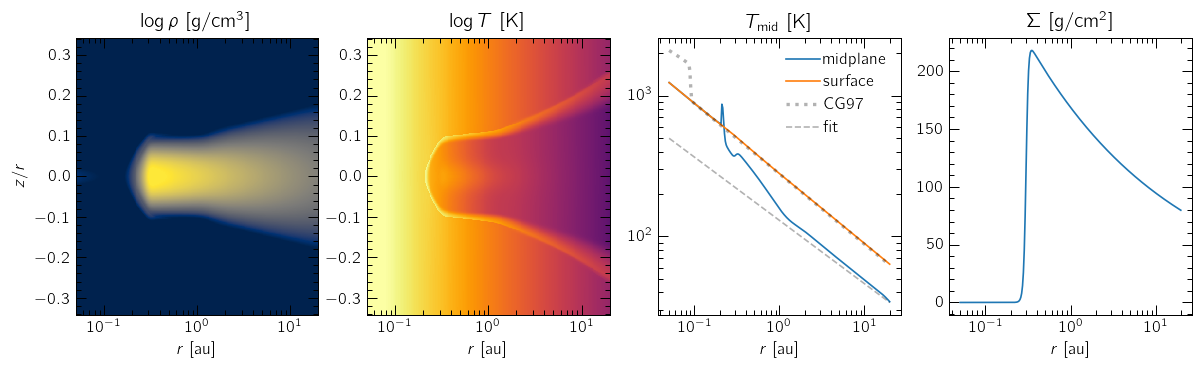

In [5]:
# ... and check the output
fig, ax = plt.subplots(ncols=4, figsize=(12, 3), dpi=120)
ax[0].pcolormesh(r, np.cos(theta), np.log10(fmt(Disk.rho).to_value('g/cm3')), cmap=plt.cm.cividis, vmin=-14, vmax=-9)
ax[0].pcolormesh(r, -np.cos(theta), np.log10(fmt(Disk.rho).to_value('g/cm3')), cmap=plt.cm.cividis, vmin=-14, vmax=-9)
ax[1].pcolormesh(r, np.cos(theta), np.log10(fmt(Disk.tmp).to_value('K')), cmap=plt.cm.inferno, vmin=1, vmax=3)
ax[1].pcolormesh(r, -np.cos(theta), np.log10(fmt(Disk.tmp).to_value('K')), cmap=plt.cm.inferno, vmin=1, vmax=3)
ax[2].plot(r, fmt(Disk.tmp).to_value('K')[mid], label='midplane') # last index is the midplane
ax[2].plot(r, fmt(Disk.tmp).to_value('K')[1], label='surface') # surface
ax[3].plot(r, (fmt(Disk.rho * grid.dz)).sum(0).to_value('g/cm2')) # surface density

for axis in ax: axis.set_xscale('log')
ax[2].set_yscale('log')


# Chiang Goldreich 1997 opt. thin analytical solution
kappaStar, kappaDisk = fmt(Gas.kappaPstar*np.ones(grid.shape)), fmt(Gas.kappaP*np.ones(grid.shape))
kappaStar += fmt(Dust.rho/Gas.rho * Dust.kappaPstar)
kappaDisk += fmt(Dust.rho/Gas.rho * Dust.kappaP)
opac_factor = (kappaStar/kappaDisk)[0] ** 0.25
TCC97 = (star.T * np.sqrt(0.5*star.R/grid.x1[grid.act1])).to_value('K') * opac_factor
ax[2].plot(r, TCC97, ls=':', c='k', alpha=0.3, lw=2, label='CG97')

ax[2].plot(r, 130 * r ** -0.45, ls='--', lw=1, c='k', alpha=0.3, label='fit')

ax[2].legend()

for axis in ax: axis.set_xlabel(r'$r$ [au]')
ax[0].set_ylabel(r'$z/r$')
ax[0].set_title(r'$\log\rho$ [g/cm${}^3$]')
ax[1].set_title(r'$\log T$ [K]')
ax[2].set_title(r'$T_\mathrm{mid}$ [K]')
ax[3].set_title(r'$\Sigma$ [g/cm${}^2$]')

plt.show()